#**PHẦN 1:  KIỂM TRA, LÀM SẠCH VÀ XỬ LÍ DỮ LIỆU**

##**1.1. Import các thư viện và xử lý dữ liệu**

In [ ]:
#Import Thư viện Pandas, matplotlib và seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime as datetime
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


In [ ]:
# Import file dữ liệu excel, và nhìn tổng thể dữ liệu
df = pd.read_excel('/content/drive/MyDrive/Adidas US Sales Datasets.xlsx',skiprows=4) # skiprows=4 vì data có title bắt đầu từ dòng số 5, index = 4
df.head()

,Unnamed: 0,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,NaN,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store
1,NaN,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store
2,NaN,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store
3,NaN,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store
4,NaN,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store


In [ ]:
# cột đầu tiên trong data gốc là cột A rỗng, nên khi import vào pandas cột đầu tiên sẽ NaN, cần ignore đi và reset lại index
df = df.dropna(axis=1, how="all")
df.reset_index(drop=True, inplace=True)
# kiểm tra lại dữ liệu
display(df.head(10))
display(df.shape)

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store
5,Foot Locker,1185732,2020-01-06,Northeast,New York,New York,Women's Apparel,50.0,1000,500000.0,125000.0,0.25,In-store
6,Foot Locker,1185732,2020-01-07,Northeast,New York,New York,Men's Street Footwear,50.0,1250,625000.0,312500.0,0.50,In-store
7,Foot Locker,1185732,2020-01-08,Northeast,New York,New York,Men's Athletic Footwear,50.0,900,450000.0,135000.0,0.30,Outlet
8,Foot Locker,1185732,2020-01-21,Northeast,New York,New York,Women's Street Footwear,40.0,950,380000.0,133000.0,0.35,Outlet
9,Foot Locker,1185732,2020-01-22,Northeast,New York,New York,Women's Athletic Footwear,45.0,825,371250.0,129937.5,0.35,Outlet


(9648, 13)

In [ ]:
# kiểm tra thông tin chung của dữ liệu -- > không có dòng dữ liệu null, kiểu dữ liệu ok, dữ liệu cơ bản đã sạch
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   object        
 1   Retailer ID       9648 non-null   int64         
 2   Invoice Date      9648 non-null   datetime64[ns]
 3   Region            9648 non-null   object        
 4   State             9648 non-null   object        
 5   City              9648 non-null   object        
 6   Product           9648 non-null   object        
 7   Price per Unit    9648 non-null   float64       
 8   Units Sold        9648 non-null   int64         
 9   Total Sales       9648 non-null   float64       
 10  Operating Profit  9648 non-null   float64       
 11  Operating Margin  9648 non-null   float64       
 12  Sales Method      9648 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(6)
memory usage: 980.0+ KB


In [ ]:
# check duplicate --> không có dữ liệu bị trùng lặp
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe() # sử dụng describe để kiểm tra tổng quan dữ liệu của các cột số

,Retailer ID,Invoice Date,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
count,9.648000e+03,9648,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000
mean,1.173850e+06,2021-05-10 15:20:44.776119296,45.216625,256.930037,93273.437500,34425.244761,0.422991
min,1.128299e+06,2020-01-01 00:00:00,7.000000,0.000000,0.000000,0.000000,0.100000
25%,1.185732e+06,2021-02-17 00:00:00,35.000000,106.000000,4254.500000,1921.752500,0.350000
50%,1.185732e+06,2021-06-04 00:00:00,45.000000,176.000000,9576.000000,4371.420000,0.410000
75%,1.185732e+06,2021-09-16 00:00:00,55.000000,350.000000,150000.000000,52062.500000,0.490000
max,1.197831e+06,2021-12-31 00:00:00,110.000000,1275.000000,825000.000000,390000.000000,0.800000
std,2.636038e+04,NaN,14.705397,214.252030,141916.016727,54193.113713,0.097197


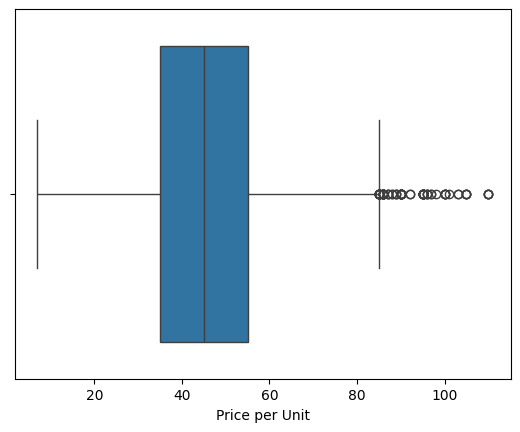

In [ ]:
# biểu đồ Boxplot kiểm tra sự phân tán dữ liệu của cột Price per Unit
sns.boxplot(x=df['Price per Unit'])
plt.show()

 **Kiểm tra cột `Price per Unit` thông qua mô tả ở trên và biểu đồ boxplot**
- Đánh giá: Giá tập trung tốt, biểu đồ lệch không mạnh
- Phân tích biểu đồ boxplot cho thấy một số giá trị Giá trên mỗi đơn vị cao cấp nằm trên giới hạn trên của khoảng tứ phân vị (IQR). Tuy nhiên, những mức giá này vẫn nằm trong phạm vi kinh doanh hợp lý đối với các sản phẩm cao cấp.



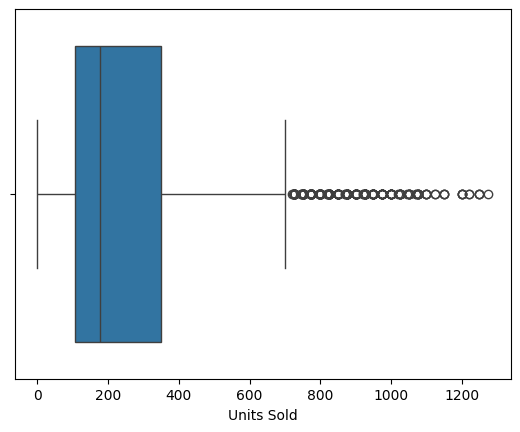

In [ ]:
# Biểu đồ boxplot kiểm tra sự phân phối dữ liệu trên cột Units Sold
sns.boxplot(x=df['Units Sold'])
plt.show()


**Kiểm tra cột `Units sold`, `Total sales`, `Operating Profit`, xử lí giá trị outliers**
- Theo mô tả dữ liệu df.describe() ở trên + biểu đồ boxplot bên dưới: cột Units sold có giá trị max cao bất thường, sử dụng boxplot để kiểm tra sự phân phối dữ liệu và kết luận rằng:  có outliers, biểu đồ phân phối lệch phải, không chỉ là 1 điểm bất thường mà là cả 1 nhóm;
- Không phải lỗi dữ liệu mà có thể là: sự đặt hàng với đơn hàng lớn, cần phân tích để thấy được insights của việc đặt hàng này mang tính chất đơn sỉ, hay ảnh hưởng của chương trình khuyến mãi hoặc nhà phân phối quy mô lớn...
- Cột `Total sales`, `Operating Profit` là hệ quả từ Units Sold * Price per Unit, với sự ảnh hưởng mạnh từ Units Sold nên sẽ không xử lý giá trị ngoại lai trên 2 cột này nữa, mà sẽ phân tích mức ảnh hưởng của số lượng sản phẩm bán ra sẽ tác động như thế nào tới doanh thu và lợi nhuận

In [ ]:
# Lập công thức để kiểm tra giá trị ngoại lai
Q1 = df['Units Sold'].quantile(0.25)
Q3 = df['Units Sold'].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1-1.5*IQR
upper_bound  = Q3 +1.5*IQR
display(lower_bound, upper_bound)
# tạo thêm cột Outlier_Type
df['Outlier_Type'] = 'Normal'
df.loc[df['Units Sold'] > upper_bound, 'Outlier_Type'] = 'High Outlier'
df.loc[df['Units Sold'] < lower_bound, 'Outlier_Type'] = 'Low Outlier'

df.head()

np.float64(-260.0)

np.float64(716.0)

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method,Outlier_Type
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store,High Outlier
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store,High Outlier
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store,High Outlier
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store,High Outlier
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store,High Outlier


**Tách cột `Product` làm 3 cột: `Gender`/`Category`/`Style` phục vụ cho việc phân tích dữ liệu**

In [ ]:
# Tách Gender
df["Gender"] = df["Product"].str.extract(r"^(.*?)'s")

# Bỏ phần Gender khỏi Product
df["Remain"] = df["Product"].str.replace(r"^.*?'s\s*", "", regex=True)

# Tạo Category (Footwear / Apparel)
df["Category"] = df["Remain"].str.split().str[-1]

# Tạo Style (chỉ có ở Footwear)
df["Style"] = df["Remain"].str.replace(" Footwear", "", regex=False)
df.loc[df["Category"] == "Apparel", "Style"] = None

# Dọn cột trung gian
df.drop(columns="Remain", inplace=True)

# sắp xếp lại vị trí các cột
df = df[
    [
        'Retailer',
        'Retailer ID',
        'Invoice Date',
        'Region',
        'State',
        'City',
        'Product',
        'Gender',
        'Category',
        'Style',
        'Sales Method',
        'Price per Unit',
        'Units Sold',
        'Total Sales',
        'Operating Profit',
        'Operating Margin',
        'Outlier_Type'
    ]
]
# xem lại dữ liệu sau khi tách cột Product thành 3 cột Gender/Category/Style
display(df.head())

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Gender,Category,Style,Sales Method,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Outlier_Type
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,Men,Footwear,Street,In-store,50.0,1200,600000.0,300000.0,0.50,High Outlier
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,Men,Footwear,Athletic,In-store,50.0,1000,500000.0,150000.0,0.30,High Outlier
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,Women,Footwear,Street,In-store,40.0,1000,400000.0,140000.0,0.35,High Outlier
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,Women,Footwear,Athletic,In-store,45.0,850,382500.0,133875.0,0.35,High Outlier
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,Men,Apparel,None,In-store,60.0,900,540000.0,162000.0,0.30,High Outlier


In [ ]:
# Kiểm tra lại dữ liệu, gồm 9648 dòng và 17 cột
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   object        
 1   Retailer ID       9648 non-null   int64         
 2   Invoice Date      9648 non-null   datetime64[ns]
 3   Region            9648 non-null   object        
 4   State             9648 non-null   object        
 5   City              9648 non-null   object        
 6   Product           9648 non-null   object        
 7   Gender            9648 non-null   object        
 8   Category          9648 non-null   object        
 9   Style             6434 non-null   object        
 10  Sales Method      9648 non-null   object        
 11  Price per Unit    9648 non-null   float64       
 12  Units Sold        9648 non-null   int64         
 13  Total Sales       9648 non-null   float64       
 14  Operating Profit  9648 n

##**1.2. lưu file dưới dạng CSV**

In [ ]:
# lưu file dữ liệu có tên Adidas dưới định dạng CSV --> phục vụ cho việc trực quan hóa dữ liệu trên PBI.
df.to_csv('Adidas_final.csv', index= False)

#**PHẦN 2: EDA DỮ LIỆU**
  (Mục đích khám phá nhanh dữ liệu, tìm insights chính và định hướng trực quan hóa PBI)

##**2.1. Kiểm tra tổng quan các thông tin liên quan**

In [ ]:
# kiểm tra số lượng khu vực kinh doanh
df['Region'].nunique()
print(f'Adidas kinh doanh trên:{df['Region'].nunique()} khu vực')

df['Region'].unique()
print(f'Bao gồm các khu vực là {df['Region'].unique()}')

#kiểm tra số lượng Retailer : 6
df['Retailer'].nunique()
print(f'Số lượng nhà bán lẻ là:{df['Retailer'].nunique()}')

print(f'Bao Gồm:{df['Retailer'].unique()}')

# Kiểm tra số lượng sản phẩm:

print(f'Số lượng sản phẩm là:{df['Product'].nunique()} sản phẩm')
print(f'Sản phẩm gồm:{df['Product'].unique()}')

# Phương thức bán hàng
print(f'các phương thức bán hàng :{df['Sales Method'].unique()}')

Adidas kinh doanh trên:5 khu vực
Bao gồm các khu vực là ['Northeast' 'South' 'West' 'Midwest' 'Southeast']
Số lượng nhà bán lẻ là:6
Bao Gồm:['Foot Locker' 'Walmart' 'Sports Direct' 'West Gear' "Kohl's" 'Amazon']
Số lượng sản phẩm là:6 sản phẩm
Sản phẩm gồm:["Men's Street Footwear" "Men's Athletic Footwear"
 "Women's Street Footwear" "Women's Athletic Footwear" "Men's Apparel"
 "Women's Apparel"]
các phương thức bán hàng :['In-store' 'Outlet' 'Online']


##**2.2. Xác định động lực tăng trưởng**


**Động lực tăng trưởng: Yếu tố nào ảnh hưởng Lợi nhuận (Operating Profit)?**
- Sử dụng mô hình **Random Forest** để lọc mối quan hệ giữa các biến đầu vào (Retailer, Region, Product, Price...) và biến mục tiêu là Lợi nhuận.

Chỉ số `Feature Importance` sẽ cho biết biến số nào quan trọng nhất.

/tmp/ipython-input-2179280840.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette="viridis")


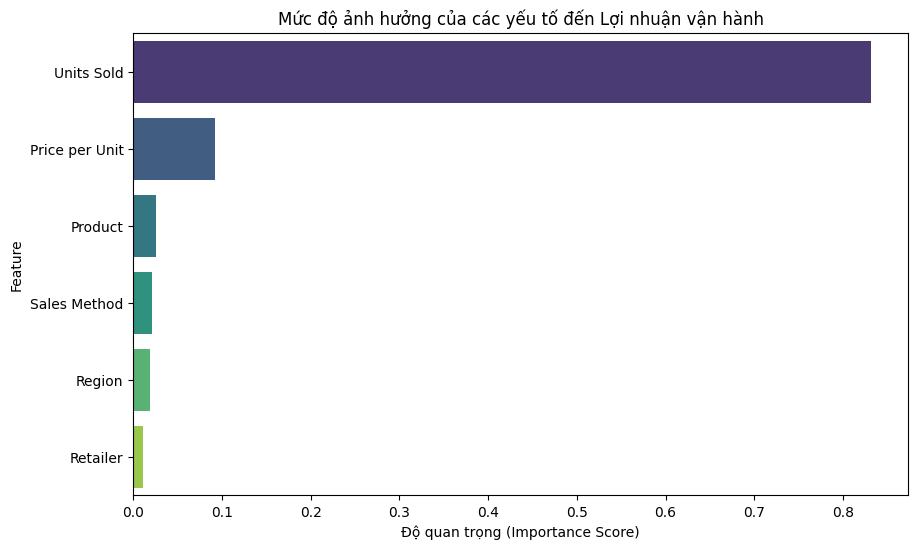

Top yếu tố ảnh hưởng nhất:


,Feature,Importance
4,Units Sold,0.832008
3,Price per Unit,0.092425
2,Product,0.025353
5,Sales Method,0.020707
1,Region,0.019054
0,Retailer,0.010453


In [ ]:
# Chuẩn bị dữ liệu
df_ml = df.copy()

# Mã hóa các biến phân loại (Categorical) thành số
le = LabelEncoder()
cat_cols = ['Retailer', 'Region', 'Product', 'Sales Method']
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# Chọn features (X) và target (y)
X = df_ml[['Retailer', 'Region', 'Product', 'Price per Unit', 'Units Sold', 'Sales Method']]
y = df_ml['Operating Profit']

# Huấn luyện mô hình Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Trích xuất độ quan trọng của biến
importances = rf.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Trực quan hóa
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette="viridis")
plt.title('Mức độ ảnh hưởng của các yếu tố đến Lợi nhuận vận hành')
plt.xlabel('Độ quan trọng (Importance Score)')
plt.show()

print("Top yếu tố ảnh hưởng nhất:")
display(feat_imp_df)

**Insight**
- Bỏ qua Units Sold (sản lượng bán ra) do biến số này chắc chắn tác động trực tiếp vào lợi nhuận. Có thể thấy, Loại sản phẩm và Phương pháp bán hàng (kênh bán hàng) sẽ là yếu tố quan trọng trực tiếp ảnh hưởng. Do đó, cần để ý và đẩy mạnh bán hàng tại những kênh đem lại hiệu quả cao.

##**2.3. Phân tích theo sản phẩm**

,Category,Total Sales
0,Apparel,302767492.0
1,Footwear,597134633.0


,Product,Total Sales
2,Men's Street Footwear,208826244.0
3,Women's Apparel,179038860.0
1,Men's Athletic Footwear,153673680.0
5,Women's Street Footwear,128002813.0
0,Men's Apparel,123728632.0
4,Women's Athletic Footwear,106631896.0


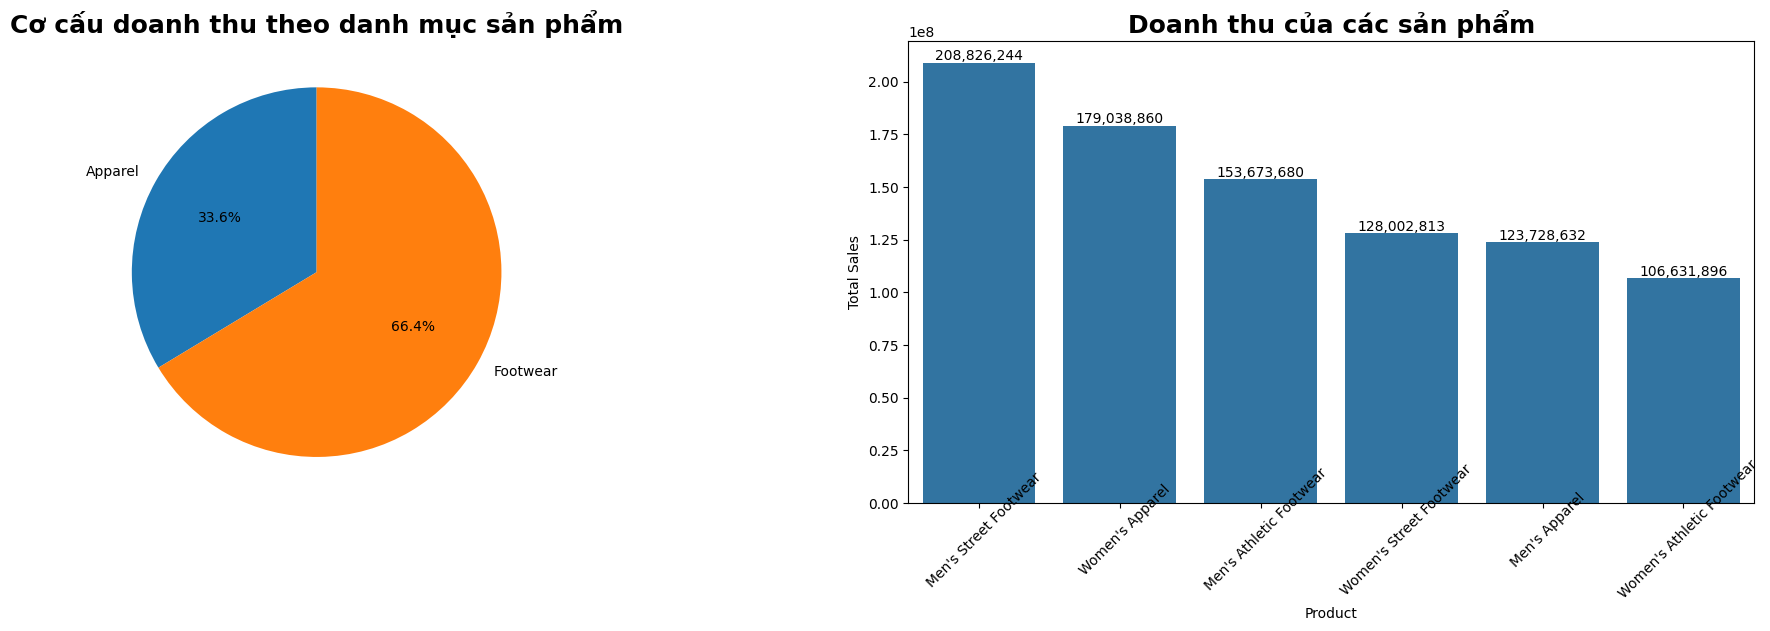

In [ ]:
# cơ cấu doanh thu theo Category và Sản phẩm
Rev_by_Cat = df.groupby('Category', as_index= False)['Total Sales'].sum()
display(Rev_by_Cat)
Rev_by_product = df.groupby('Product', as_index = False)['Total Sales'].sum()\
                                .sort_values('Total Sales', ascending = False)
display(Rev_by_product)

# Trực quan hóa
fig, axes = plt.subplots(1,2,figsize = (24,6))
# Biểu đồ 1: Cơ cấu doanh thu theo Category
labels = Rev_by_Cat['Category']
sizes = Rev_by_Cat['Total Sales']
axes[0].pie(
    sizes,
    labels = labels,
    autopct= '%1.1f%%',
    startangle= 90
)
axes[0].set_title('Cơ cấu doanh thu theo danh mục sản phẩm', fontsize= 18, fontweight = 'bold')

# Biểu đồ 2: Xác định sản phẩm bán chạy
ax = sns.barplot(
    data = Rev_by_product,
    x = 'Product',
    y = 'Total Sales',
    ax= axes[1]
)
axes[1].set_title('Doanh thu của các sản phẩm',fontsize= 18, fontweight = 'bold' )
axes[1].tick_params(axis = 'x',rotation = 45, pad=12)
plt.setp(
    axes[1].get_xticklabels(),
    ha='center',
    rotation_mode='anchor'
)
for p in ax.patches:
  height = p.get_height()
  ax.text(p.get_x()+p.get_width()/2, height, f'{height:,.0f}', ha = 'center', va = 'bottom')



- Giày dép là mặt hàng được kinh doanh chủ lực với doanh thu cao hơn 66%, Quần áo là sản phẩm bổ trợ cho doanh thu.

- Các mặt hàng Giày thể thao nam bán rất chạy. Tiếp đến là quần áo nữ. Nhìn chung các sản phẩm giày của thuộc phân khúc khách hàng nam chiến ưu thế hơn các sản phẩm giày nữ.


Giá bán trung bình của sản phẩm là:45.21662520729685


<Axes: title={'center': 'Products price distribution'}, ylabel='Frequency'>

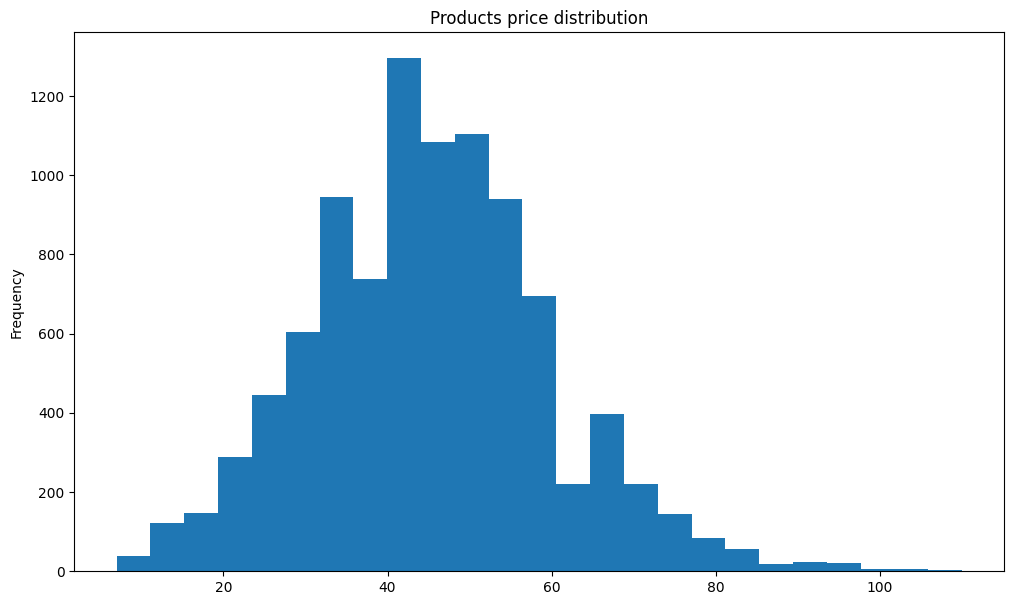

In [ ]:
df['Price per Unit'].mean()
print(f'Giá bán trung bình của sản phẩm là:{df['Price per Unit'].mean()}')
df['Price per Unit'].plot(kind='hist',bins=25,figsize=(12,7),title='Products price distribution')

,Outlier_Type,Product,Units Sold,Price per Unit,Total Sales,Operating Profit,Margin%
0,High Outlier,Men's Apparel,24200,61.833333,14963750.0,5119000.00,34.209339
1,High Outlier,Men's Athletic Footwear,84575,54.362745,45938750.0,14867437.50,32.363609
2,High Outlier,Men's Street Footwear,169935,52.216495,89325750.0,37005975.00,41.428116
3,High Outlier,Women's Apparel,73100,60.919540,44471250.0,18893187.50,42.484049
4,High Outlier,Women's Athletic Footwear,21725,51.111111,11090000.0,3566375.00,32.158476
5,High Outlier,Women's Street Footwear,56465,48.455882,27288500.0,9294537.50,34.060273
6,Normal,Men's Apparel,282483,50.102792,108764882.0,39644030.33,36.449293
7,Normal,Men's Athletic Footwear,350951,43.063660,107734930.0,36979450.69,34.324476
8,Normal,Men's Street Footwear,423385,43.143362,119500494.0,45796285.62,38.323093
9,Normal,Women's Apparel,360727,51.067719,134567610.0,49757783.06,36.976047


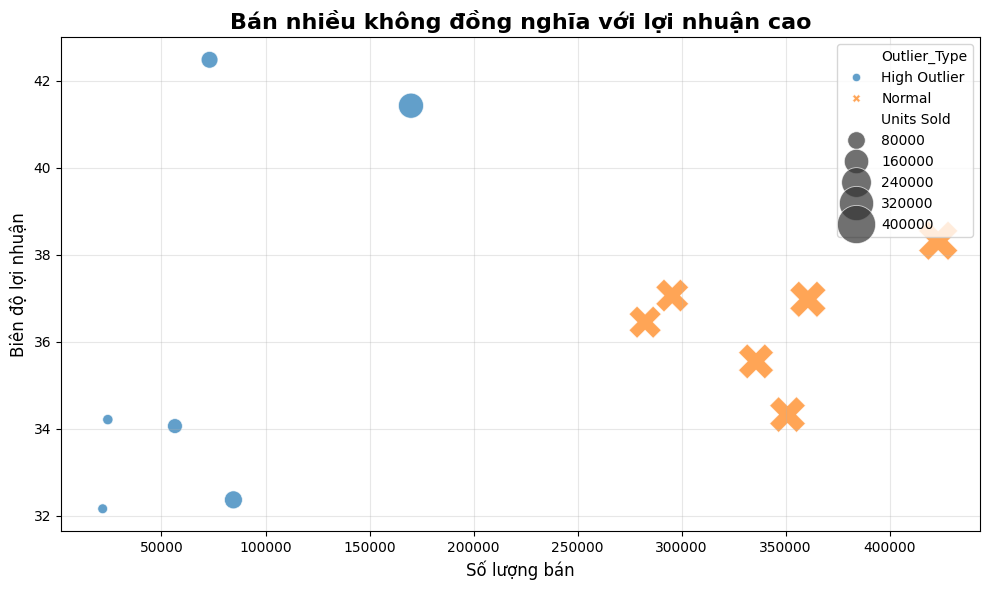

In [ ]:
df_outlier= df.groupby(['Outlier_Type','Product'], as_index= False).agg({\
                                             'Units Sold': 'sum'
                                             ,'Price per Unit': 'mean'
                                             ,'Total Sales':'sum'
                                             ,'Operating Profit':'sum'
                                             })
df_outlier['Margin%'] = df_outlier['Operating Profit']*100/df_outlier['Total Sales']
display(df_outlier)
# trực quan hóa:
plt.figure(figsize=(10,6))

ax = sns.scatterplot(
    data=df_outlier,
    x='Units Sold',
    y='Margin%',
    hue='Outlier_Type',
    style='Outlier_Type',
    size='Units Sold',
    sizes=(50, 800),            # kiểm soát độ to nhỏ
    alpha=0.7
)

plt.title(
    'Bán nhiều không đồng nghĩa với lợi nhuận cao',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('Số lượng bán', fontsize=12)
plt.ylabel('Biên độ lợi nhuận', fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- **High Outlier**
Một số sản phẩm:
Volume thấp
Margin cao
→ Khả năng:
Giá bán cao
Định vị premium
Chi phí được kiểm soát tốt
- **Normal**
Bán nhiều nhưng:
Margin trung bình / thấp
→ Có thể:
Giảm giá để đẩy volume
Chi phí vận hành / logistics cao
Cạnh tranh giá mạnh
>
<mark>
“Biểu đồ scatter cho thấy mối quan hệ giữa sản lượng và biên lợi nhuận là không tuyến tính.
Một số sản phẩm bán với sản lượng thấp nhưng đạt biên lợi nhuận cao hơn đáng kể so với các sản phẩm bán số lượng lớn.
Điều này nhấn mạnh rằng chiến lược tối ưu lợi nhuận cần tập trung vào cấu trúc chi phí, giá bán và phân khúc sản phẩm, thay vì chỉ mở rộng sản lượng.”
</mark>

Units Sold  Total Sales  \
Outlier_Type Product                                              
Normal       Men's Street Footwear          423385  119500494.0   
             Women's Apparel                360727  134567610.0   
             Men's Athletic Footwear        350951  107734930.0   
             Women's Street Footwear        335804  100714313.0   
             Women's Athletic Footwear      295511   95541896.0   
             Men's Apparel                  282483  108764882.0   
High Outlier Men's Street Footwear          169935   89325750.0   
             Men's Athletic Footwear         84575   45938750.0   
             Women's Apparel                 73100   44471250.0   
             Women's Street Footwear         56465   27288500.0   
             Men's Apparel                   24200   14963750.0   
             Women's Athletic Footwear       21725   11090000.0   

                                        Operating Profit  Operating Margin  \
Outlier_Type Product                                                         
Normal       Men's Street Footwear           45796285.62          0.450544   
             Women's Apparel                 49757783.06          0.441512   
             Men's Athletic Footwear         36979450.69          0.407593   
             Women's Street Footwear         35801289.31          0.413506   
             Women's Athletic Footwear       35409409.94          0.426105   
             Men's Apparel                   39644030.33          0.414556   
High Outlier Men's Street Footwear           37005975.00          0.413918   
             Men's Athletic Footwear         14867437.50          0.330392   
             Women's Apparel                 18893187.50          0.437931   
             Women's Street Footwear          9294537.50          0.335294   
             Men's Apparel                    5119000.00          0.343333   
             Women's Athletic Footwear        3566375.00          0.322222   

                                          %Margin  
Outlier_Type Product                               
Normal       Men's Street Footwear      38.323093  
             Women's Apparel            36.976047  
             Men's Athletic Footwear    34.324476  
             Women's Street Footwear    35.547370  
             Women's Athletic Footwear  37.061657  
             Men's Apparel              36.449293  
High Outlier Men's Street Footwear      41.428116  
             Men's Athletic Footwear    32.363609  
             Women's Apparel            42.484049  
             Women's Street Footwear    34.060273  
             Men's Apparel              34.209339  
             Women's Athletic Footwear  32.158476

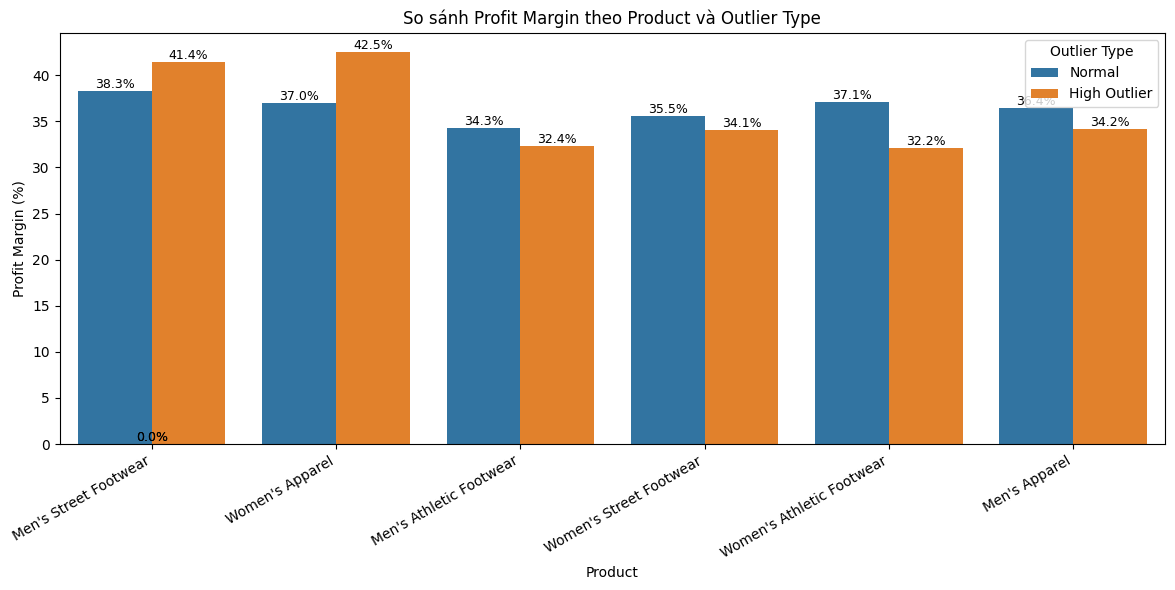

In [ ]:
Oulier_Product = df.groupby(['Outlier_Type','Product']).agg({\
                                'Units Sold':'sum'
                                ,'Total Sales': 'sum'
                                ,'Operating Profit':'sum'
                                ,'Operating Margin':'mean'
                                }).sort_values('Units Sold', ascending = False)

Oulier_Product['%Margin'] = Oulier_Product['Operating Profit']*100 /Oulier_Product['Total Sales']
display(Oulier_Product)
 # trực quan hóa:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data= Oulier_Product,
    x='Product',
    y='%Margin',
    hue='Outlier_Type'
)

plt.ylabel('Profit Margin (%)')
plt.xlabel('Product')
plt.title('So sánh Profit Margin theo Product và Outlier Type')

for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:.1f}%",
        (p.get_x() + p.get_width() / 2, value),
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

plt.xticks(rotation=30, ha='right')
plt.legend(title='Outlier Type')
plt.tight_layout()
plt.show()

**Men’s Street Footwear**, **Women’s Apparel:**
Đây là các nhóm bán chạy với sản lượng lớn và đồng thời gia tăng lợi nhuận.
→ Cần ưu tiên đẩy mạnh quy mô, mở rộng phân phối và hạn chế lạm dụng khuyến mãi để bảo toàn biên lợi nhuận.

**Women’s Street Footwear, Men’s Apparel:**
Các nhóm này duy trì biên lợi nhuận ở mức ổn định, đóng vai trò nền doanh thu.
→ Chiến lược phù hợp là duy trì doanh thu hiện tại, kết hợp upsell/cross-sell các sản phẩm có biên lợi nhuận cao hơn.

**Men’s Athletic Footwear, Women’s Athletic Footwear:**
Dù bán với sản lượng lớn, các nhóm này lại làm suy giảm biên lợi nhuận.
→ Cần kiểm soát hoạt động khuyến mãi, tối ưu chi phí vận hành hoặc xem xét điều chỉnh chiến lược giá.

Hệ số tương quan giữa Giá và Lượng bán (Dương = Giá tăng Lượng tăng):


,Product,Correlation
3,Women's Athletic Footwear,0.344536
1,Men's Athletic Footwear,0.331020
4,Men's Apparel,0.314764
2,Women's Street Footwear,0.299713
5,Women's Apparel,0.267720
0,Men's Street Footwear,0.252120


<Figure size 1200x600 with 0 Axes>

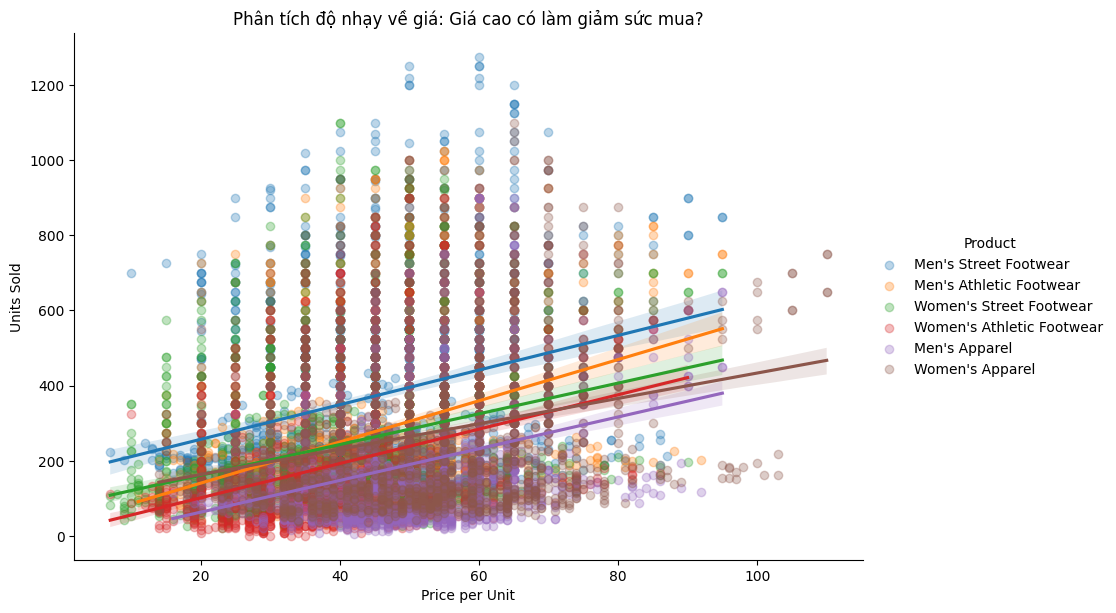

In [ ]:
products = df['Product'].unique()

# Tính hệ số tương quan cho từng sản phẩm
elasticity_data = []
for p in products:
    subset = df[df['Product'] == p]
    # Tính correlation
    corr = subset['Price per Unit'].corr(subset['Units Sold'])
    elasticity_data.append({'Product': p, 'Correlation': corr})

elasticity_df = pd.DataFrame(elasticity_data).sort_values('Correlation', ascending=False)

print("Hệ số tương quan giữa Giá và Lượng bán (Dương = Giá tăng Lượng tăng):")
display(elasticity_df)
# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.lmplot(x='Price per Unit', y='Units Sold', data=df, hue='Product', height=6, aspect=1.5, scatter_kws={'alpha':0.3})
plt.title('Phân tích độ nhạy về giá: Giá cao có làm giảm sức mua?')
plt.show()

**Insight:** Correlation là DƯƠNG (~0.25 - 0.35): ám chỉ sản phẩm Adidas trong bộ dữ liệu này hoạt động như một loại hàng hóa có thương hiệu mạnh (Veblen goods) hoặc dữ liệu phản ánh việc tăng giá thành công trong các đợt cao điểm (Peak season) mà không làm giảm cầu.

> Có dư địa để thử nghiệm tăng giá (Price testing) ở các phân khúc bán chạy nhất mà không sợ mất khách.

##**2.4.Phân tích theo kênh bán hàng**

**Kiểm định thống kê: Kênh bán hàng nào hiệu quả nhất?**
- sử dụng ANOVA (Analysis of Variance) để kiểm tra xem có sự khác biệt có ý nghĩa thống kê về Operating Margin giữa 3 phương thức bán hàng: In-store, Online, và Outlet hay không.

H0 (Giả thuyết null): Không có sự khác biệt về Margin giữa các kênh.
H1 (Giả thuyết đối): Có ít nhất một kênh có Margin khác biệt đáng kể so với các kênh còn lại.

In [ ]:
# Chuẩn bị dữ liệu
methods = df['Sales Method'].unique()
groups = [df[df['Sales Method'] == method]['Operating Margin'] for method in methods]

# Thực hiện kiểm định
f_val, p_val = stats.f_oneway(*groups)

print(f"Kết quả: F-value = {f_val:.2f}, P-value = {p_val}")

if p_val < 0.05:
    print("=> Kết luận: Có sự khác biệt CÓ Ý NGHĨA THỐNG KÊ về biên lợi nhuận giữa các kênh bán hàng.")
else:
    print("=> Kết luận: Không đủ bằng chứng để khẳng định sự khác biệt.")

Kết quả: F-value = 1224.08, P-value = 0.0
=> Kết luận: Có sự khác biệt CÓ Ý NGHĨA THỐNG KÊ về biên lợi nhuận giữa các kênh bán hàng.


,Sales Method,Qty,sales,Profits
1,Online,4889,247672882.0,9.655518e+07
2,Outlet,3019,295585493.0,1.079883e+08
0,In-store,1740,356643750.0,1.275913e+08


,Sales Method,Qty,sales,Profits,Margin%
1,Online,4889,247672882.0,9.655518e+07,38.984961
2,Outlet,3019,295585493.0,1.079883e+08,36.533693
0,In-store,1740,356643750.0,1.275913e+08,35.775557


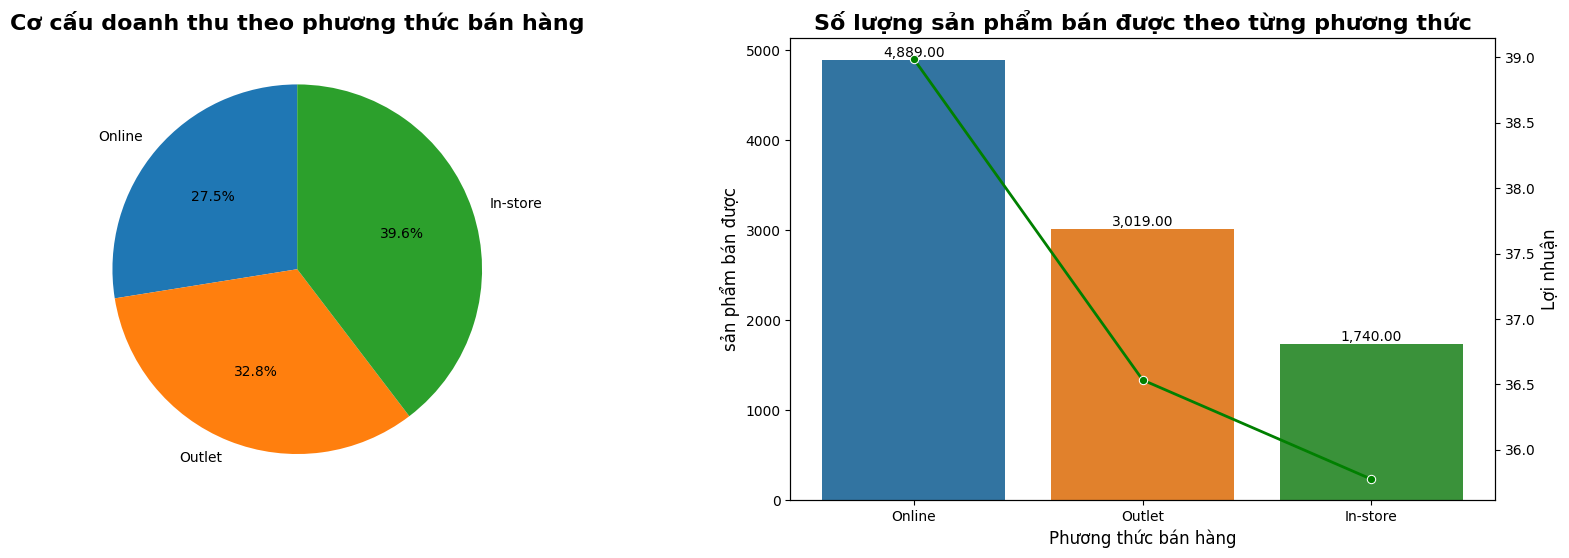

In [ ]:
# Doanh thu theo phương thức bán hàng

df1 = df.groupby('Sales Method', as_index= False).agg(Qty = ('Units Sold','count'), sales = ('Total Sales','sum'), Profits = ('Operating Profit','sum'))
Rev_by_sales_method = df1.sort_values('sales', ascending =True)
display(Rev_by_sales_method)
Units_by_sales_method = df1.sort_values('Qty', ascending =False)
Units_by_sales_method['Margin%'] = Units_by_sales_method['Profits']*100/Units_by_sales_method['sales']
display(Units_by_sales_method)

#Trực quan hóa
fig, axes = plt.subplots(1,2, figsize=(20,6))
#Biểu đồ 1: Cơ cấu doanh thu theo phương thức bán hàng
sizes = Rev_by_sales_method['sales']
labels = Rev_by_sales_method['Sales Method']
axes[0].pie(
    sizes,
    labels = labels,
    autopct = '%1.1f%%',
    startangle = 90
)
axes[0].set_title('Cơ cấu doanh thu theo phương thức bán hàng', fontsize = 16, fontweight = 'bold')
# Biểu đồ 2: Số lượng sản phẩm bán được theo từng phương thức
ax = sns.barplot(
    data = Units_by_sales_method,
    x = 'Sales Method',
    y= 'Qty',
    ax = axes[1],
    hue = 'Sales Method'
)
axes[1].set_title('Số lượng sản phẩm bán được theo từng phương thức', fontsize = 16, fontweight = 'bold')
axes[1].set_xlabel('Phương thức bán hàng', fontsize =12)
axes[1].set_ylabel('sản phẩm bán được', fontsize =12)
for p in ax.patches:
  height = p.get_height()
  ax.text(p.get_x()+p.get_width()/2,height, f'{height:,.2f}', ha = 'center', va='bottom')
# Trục Y thứ 2 cho lợi nhuận
ax2 = axes[1].twinx()\

sns.lineplot(
    data = Units_by_sales_method,
    x='Sales Method',
    y='Margin%',
    ax=ax2,
    marker='o',
    linewidth=2,
    color = 'Green'
)

ax2.set_ylabel('Lợi nhuận', fontsize=12)

# Căn layout cho đẹp
axes[1].tick_params(axis='x', rotation=0)


👉Doanh thu hiện vẫn phụ thuộc lớn vào kênh In-store, cho thấy cửa hàng vật lý giữ vai trò chủ lực trong việc tạo doanh thu. Tuy nhiên, In-store không phải kênh bán nhiều sản phẩm nhất. Điều này gợi ý giá trị đơn hàng (AOV) cao hơn so với Online & Outlet. In-store đóng vai trò đóng góp doanh thu lớn, nhưng hiệu quả lợi nhuận trên mỗi sản phẩm còn thấp.

👉 Online là kênh volume-driven (bán nhiều, tần suất cao), là kênh có hiệu quả kinh doanh tốt nhất khi vừa dẫn đầu về sản lượng vừa có biên lợi nhuận cao --> Đẩy Online: upsell / bundle để tăng doanh thu trên nền margin cao

👉 Tối ưu In-store:

- Kiểm soát chi phí vận hành

- Tăng cross-sell để cải thiện margin

👉 Outlet: giữ vai trò kênh hỗ trợ tồn kho, không nên là trọng tâm tăng trưởng

##**2.5. Phân tích theo khu vực**

In [ ]:
# tạo thêm các cột năm, tháng_năm, quý_năm phục vụ việc phân tích theo thời gian
df['Year'] = df['Invoice Date'].dt.year
df['Month_Year'] = df['Invoice Date'].dt.to_period('M').astype(str)
df['Quarter_Year'] = df['Invoice Date'].dt.to_period('Q').astype(str)

df.head()


,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Gender,Category,Style,Sales Method,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Outlier_Type,Year,Month_Year,Quarter_Year
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,Men,Footwear,Street,In-store,50.0,1200,600000.0,300000.0,0.50,High Outlier,2020,2020-01,2020Q1
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,Men,Footwear,Athletic,In-store,50.0,1000,500000.0,150000.0,0.30,High Outlier,2020,2020-01,2020Q1
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,Women,Footwear,Street,In-store,40.0,1000,400000.0,140000.0,0.35,High Outlier,2020,2020-01,2020Q1
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,Women,Footwear,Athletic,In-store,45.0,850,382500.0,133875.0,0.35,High Outlier,2020,2020-01,2020Q1
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,Men,Apparel,None,In-store,60.0,900,540000.0,162000.0,0.30,High Outlier,2020,2020-01,2020Q1


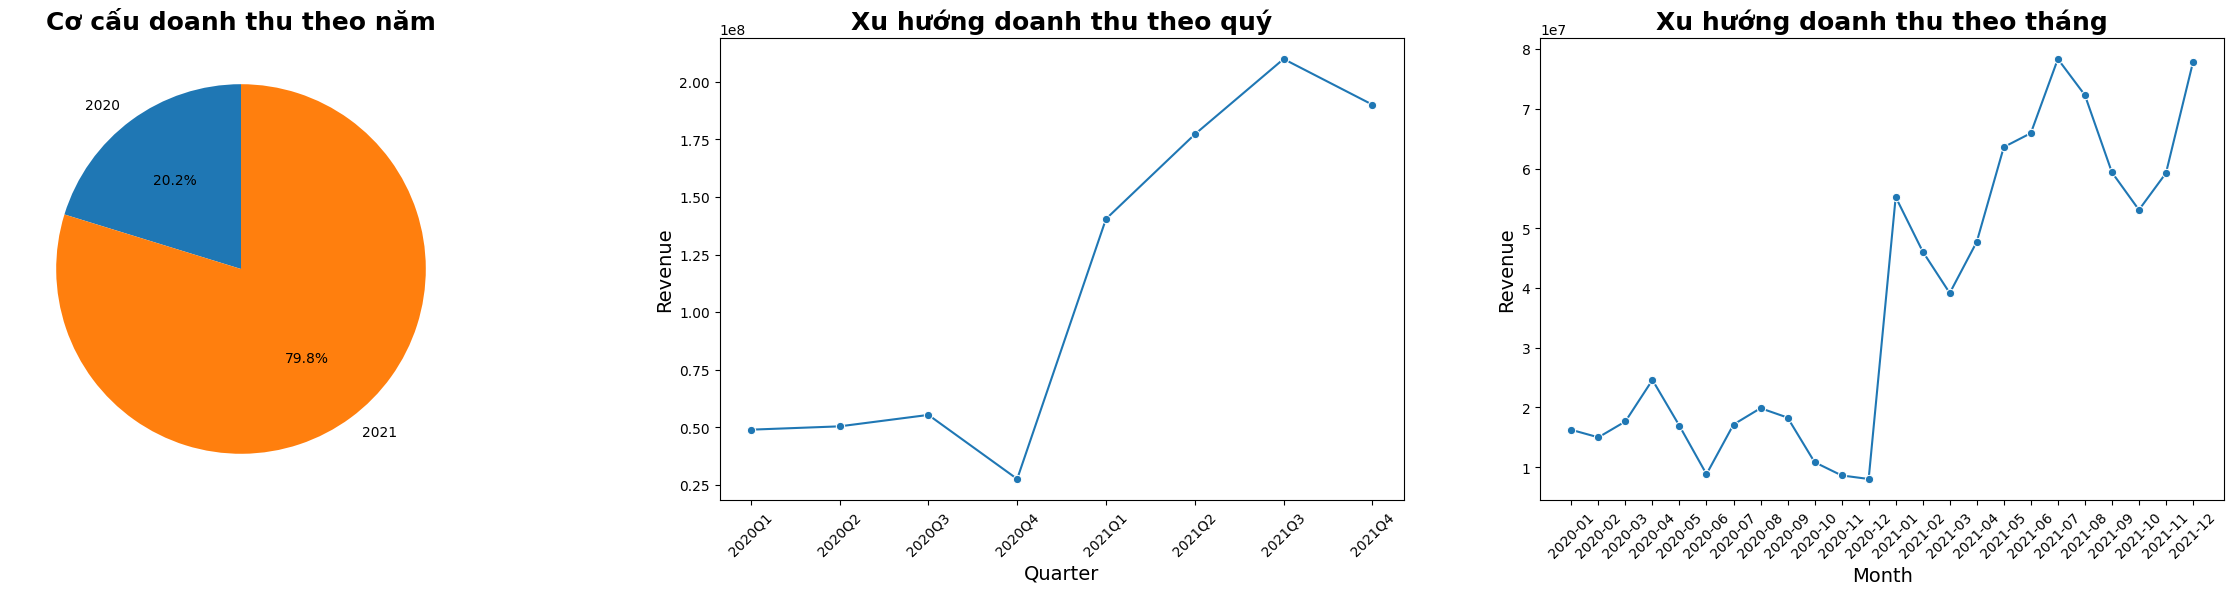

In [ ]:
# Doanh thu theo năm
Rev_by_year= df.groupby('Year', as_index= False)['Total Sales'].sum()
# Doanh thu theo tháng
Rev_by_month= df.groupby('Month_Year', as_index= False)['Total Sales'].sum()

# Doanh thu theo quý
Rev_by_quarter= df.groupby('Quarter_Year', as_index= False)['Total Sales'].sum()

# Biểu đồ thể hiện cơ cấu doanh thu theo năm và xu hướng theo thời gian
fig, axes = plt.subplots(1, 3, figsize=(30, 6))
# Biểu đồ 1: cơ cấu doanh thu theo thời gian:
labels = Rev_by_year['Year']
sizes = Rev_by_year['Total Sales']
axes[0].pie(
    sizes,
    labels = labels,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Cơ cấu doanh thu theo năm', fontsize =18, fontweight = 'bold')
#Biểu đồ 2: Thể hiện doanh thu theo quý của từng năm
sns.lineplot(
    data  =Rev_by_quarter,
    x = 'Quarter_Year',
    y = 'Total Sales',
    ax= axes[1],
    marker = 'o'
)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Xu hướng doanh thu theo quý', fontsize =18, fontweight = 'bold')
axes[1].set_xlabel('Quarter', fontsize =14)
axes[1].set_ylabel('Revenue', fontsize =14)

# biểu đồ 3: xu hướng doanh thu theo tháng

sns.lineplot(
    data  =Rev_by_month,
    x = 'Month_Year',
    y = 'Total Sales',
    ax= axes[2],
    marker = 'o'
)
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_title('Xu hướng doanh thu theo tháng', fontsize =18, fontweight = 'bold')
axes[2].set_xlabel('Month', fontsize =14)
axes[2].set_ylabel('Revenue', fontsize =14)

plt.show()


**Nhận xét:**
 - Năm 2020 chịu ảnh hưởng của dịch covid 19 nên doanh thu không đáng kể, năm 2021 đã ổn định được thị trường và nhu cầu mua sắm tăng cao.
 - Các tháng đầu năm có doanh thu thấp, bắt đầu tăng lên từ Quý 2. Đặc biệt là Quý 3, có sự giảm nhẹ nhưng vẫn ở mức doanh thu cao ở Quý 4.
<mark>
 Xu hướng bán hàng có sự ảnh hưởng theo mùa, khi các sản phẩm thể thao được ưa chuộng ở các tháng mùa hè, và các tháng có lễ hội vào cuối năm. Có thể xây dựng chiến lược để đẩy mạnh được sản phẩm vào các tháng cao điểm.
 </mark>

,count_state,count_city
Region,,
Midwest,13,13
Northeast,12,13
South,7,8
Southeast,6,7
West,12,13


,Region,Qty,Total_sales,Total_profits,Avg_margin
0,Midwest,391337,135800459.0,52811346.48,0.435272
2,South,492260,144663181.0,61138004.07,0.466898
3,Southeast,407000,163171236.0,60555416.70,0.419167
1,Northeast,501279,186324067.0,68020587.65,0.410450
4,West,686985,269943182.0,89609406.55,0.396691


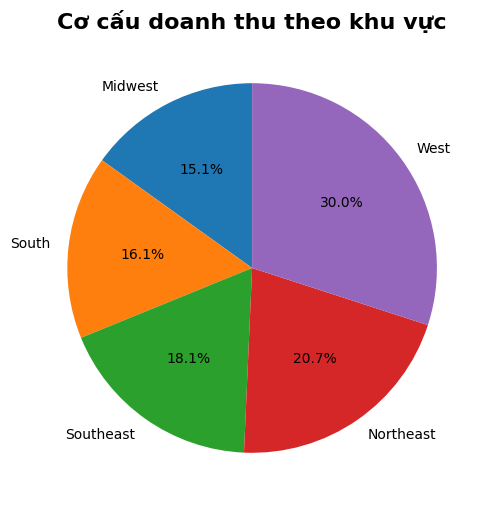

In [ ]:
# kiểm tra số lượng State và City theo từng Region, để đánh giá khu vực
display(df.groupby(['Region']).agg(count_state = ('State','nunique'),count_city = ('City','nunique')))
# kiểm tra số lượng sản phẩm bán ra, doanh thu, lợi nhuận theo từng khu vực. Kết hợp chart PBI để phân tích báo cáo
Rev_by_region = df.groupby('Region', as_index = False).agg(Qty= ('Units Sold','sum'), Total_sales = ('Total Sales','sum'), Total_profits = ('Operating Profit','sum'),Avg_margin=('Operating Margin', 'mean'))\
                                                                                              .sort_values('Total_sales', ascending = True)
display(Rev_by_region)
# Biểu đồ cơ cấu doanh thu theo khu vực
labels = Rev_by_region['Region']
sizes = Rev_by_region['Total_sales']
plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels = labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Cơ cấu doanh thu theo khu vực', fontsize =16, fontweight = 'bold')
plt.show()

<mark>
Khu vực phía Tây chiếm tỉ trọng doanh thu cao cần tiếp tục đầu tư phát triển, Đông Bắc và Đông Nam tương đối đồng đều, ổn định. Phía Nam và Phía Trung Tây số lượng thành phố còn nhiều, và còn dư địa để phát triển.
</mark>

##**2.6. Phân tích theo nhà bán lẻ**

,Retailer,Qty,Total_sales,Total_Profits
4,Walmart,206225,74558410.0,25782052.61
0,Amazon,197990,77698912.0,28818503.31
2,Kohl's,287375,102114753.0,36811252.58
3,Sports Direct,557640,182470997.0,74332954.96
1,Foot Locker,604369,220094720.0,80722124.81
5,West Gear,625262,242964333.0,85667873.18


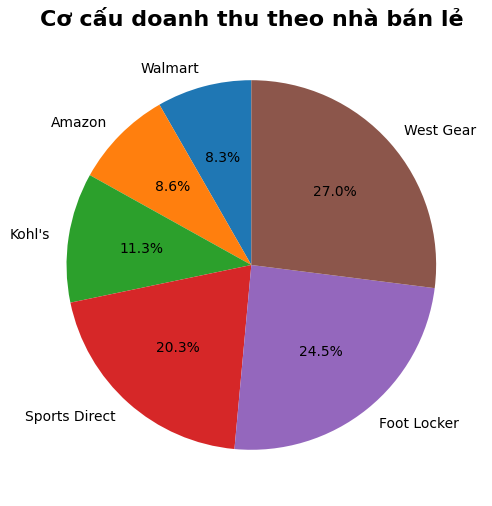

In [ ]:
# kiểm  tra số lượng sản phẩm bán ra, doanh thu, lợi nhuận theo từng nhà bán lẻ, kết hợp biểu đồ trực quan trên PBI để phân tích
Rev_by_retailer = df.groupby('Retailer', as_index = False ).agg(Qty= ('Units Sold','sum'),Total_sales = ('Total Sales','sum'), Total_Profits =('Operating Profit','sum') )\
                                                                                .sort_values('Total_sales', ascending = True)
display(Rev_by_retailer)
# Biểu đồ cơ cấu doanh thu theo nhà bán lẻ
labels = Rev_by_retailer['Retailer']
sizes =Rev_by_retailer['Total_sales']
plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels = labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Cơ cấu doanh thu theo nhà bán lẻ', fontsize = 16, fontweight = 'bold')
plt.show()


<mark>
Nhà phân phối chủ lực: West Gear, Foot Locker, Sports Direct, là các nhà phân phối lớn và có độ bao phủ cao. Amazon, Walmart, Kohl's đóng góp 1 phần doanh thu không quá cao.
</mark>

##**2.7. Tương tác đa chiều Vùng miền và Kênh bán hàng**

Chúng ta biết Online có biên lợi nhuận (Margin) cao nhất toàn cục. Nhưng liệu điều này có đúng ở mọi vùng miền?

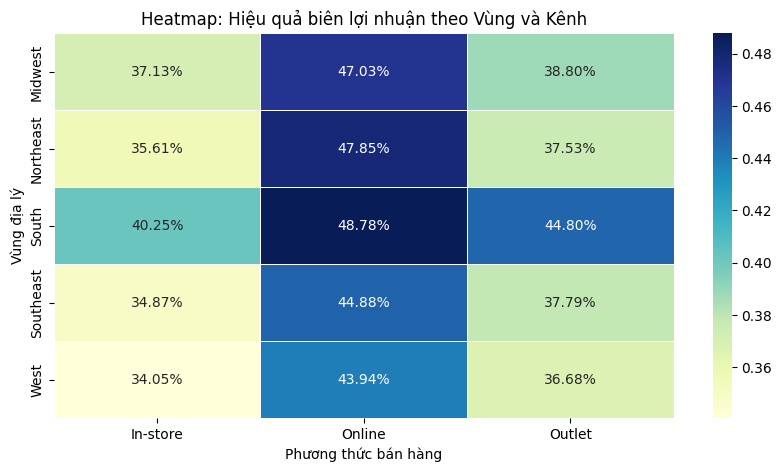

In [ ]:
# Tạo Pivot table: Index=Region, Columns=Sales Method, Values=Operating Margin
interaction = df.pivot_table(index='Region', columns='Sales Method', values='Operating Margin', aggfunc='mean')

# Vẽ Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(interaction, annot=True, cmap="YlGnBu", fmt=".2%", linewidths=.5)
plt.title('Heatmap: Hiệu quả biên lợi nhuận theo Vùng và Kênh')
plt.ylabel('Vùng địa lý')
plt.xlabel('Phương thức bán hàng')
plt.show()

**Insight**
- Margin của In-store và Outlet tại South cao hơn hẳn In-store tại West , điều này gợi ý nên mang quy trình vận hành cửa hàng tại Miền Nam áp dụng cho Miền Tây để tối ưu hóa

##**2.8. Kiểm tra xu hướng theo giới tính**

,Gender,Qty,Sales,Profits
0,Men,1335529,486228556.0,1.794122e+08
1,Women,1143332,413673569.0,1.527226e+08


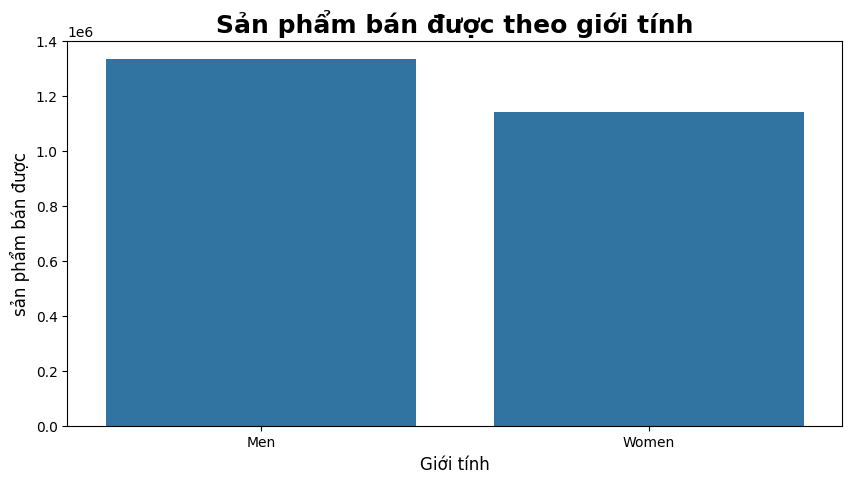

In [ ]:
# kiểm tra số lượng sản phẩm, doanh thu, lợi nhuận theo giới tính
Rev_by_Gender = df.groupby('Gender',as_index= False).agg(Qty= ('Units Sold','sum'), Sales = ('Total Sales','sum'), Profits = ('Operating Profit','sum'))\
                                                    .sort_values('Qty',ascending = False)
display(Rev_by_Gender)
# Trực quan hóa

plt.figure(figsize = (10,5))
ax = sns.barplot(
  data = Rev_by_Gender,
  x = 'Gender',
  y = 'Qty'
)
plt.title('Sản phẩm bán được theo giới tính', fontsize = 18, fontweight = 'bold')
plt.xlabel('Giới tính', fontsize =12)
plt.ylabel('sản phẩm bán được', fontsize =12)
plt.show()

<mark>
 Các sản phẩm về thể thao của adidas có sự thu hút lớn đối với khách hàng nam giới.
 </mark>

In [ ]:
df.groupby(['Outlier_Type','Category']).agg({\
                                             'Units Sold': 'sum'
                                             ,'Price per Unit': 'mean'
                                             ,'Total Sales':'sum'
                                             ,'Operating Profit':'sum'



                                             })

Units Sold  Price per Unit  Total Sales  \
Outlier_Type Category                                            
High Outlier Apparel        97300       61.153846   59435000.0   
             Footwear      332700       52.046036  173643000.0   
Normal       Apparel       643210       50.576687  243332492.0   
             Footwear     1405651       41.719179  423491633.0   

                       Operating Profit  
Outlier_Type Category                    
High Outlier Apparel       2.401219e+07  
             Footwear      6.473432e+07  
Normal       Apparel       8.940181e+07  
             Footwear      1.539864e+08

<mark>
Giá cao chủ yếu ở các sản phẩm có giá trị cao

##**2.9. Kiểm tra tương quan**

**Ma trận tương quan (Correlation Matrix)**
Kiểm tra mối quan hệ tuyến tính giữa các biến số lượng.
* **Price per Unit vs Units Sold:** Liệu giá tăng thì lượng bán có giảm?
* **Total Sales vs Operating Margin:** Doanh số cao có đồng nghĩa với biên lợi nhuận cao?

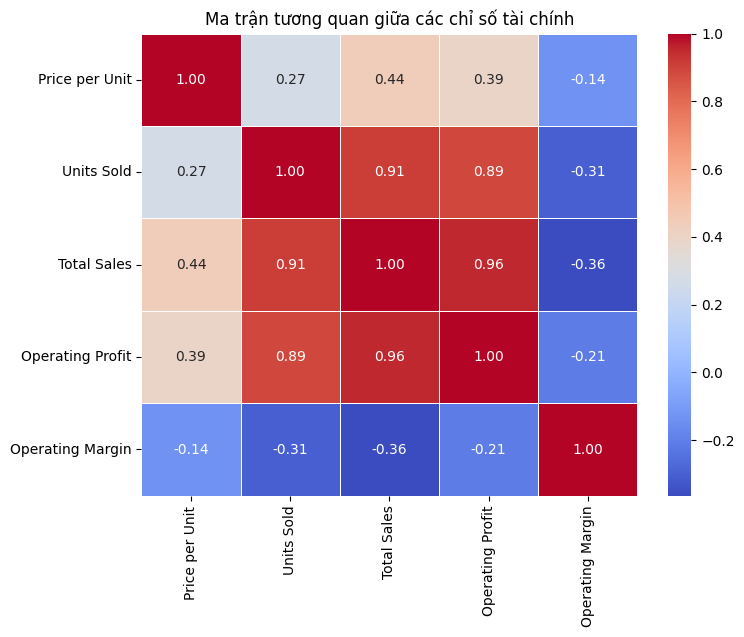

In [ ]:
# Tính ma trận tương quan
corr_cols = ['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit', 'Operating Margin']
corr_matrix = df[corr_cols].corr()

# Vẽ Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các chỉ số tài chính')
plt.show()

**Insight**
- Correlation giữa Price và Units Sold là dương (positive), điều này chỉ ra rằng: Adidas đang bán được nhiều hàng hơn ở các phân khúc giá cao (premium products) hoặc khách hàng ít nhạy cảm về giá với thương hiệu này.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score

In [ ]:
# tạo 1 bản copy
df2=df.copy()
# xóa những cột không phân tích ở df2
df2 = df2.drop(['Retailer ID','Invoice Date','Gender','Category','Style','Outlier_Type','Year','Month_Year','Quarter_Year'], axis=1)
display(df2.head())
df2['Region']=pd.factorize(df2.Region)[0]
df2['State']=pd.factorize(df2.State)[0]
df2['City']=pd.factorize(df2.City)[0]
df2['Product']=pd.factorize(df2.Product)[0]
df2['Retailer']=pd.factorize(df2.Retailer)[0]
# đổi tên cột
df2.rename(columns = {'Sales Method':'Method'}, inplace = True)

,Retailer,Region,State,City,Product,Sales Method,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
0,Foot Locker,Northeast,New York,New York,Men's Street Footwear,In-store,50.0,1200,600000.0,300000.0,0.50
1,Foot Locker,Northeast,New York,New York,Men's Athletic Footwear,In-store,50.0,1000,500000.0,150000.0,0.30
2,Foot Locker,Northeast,New York,New York,Women's Street Footwear,In-store,40.0,1000,400000.0,140000.0,0.35
3,Foot Locker,Northeast,New York,New York,Women's Athletic Footwear,In-store,45.0,850,382500.0,133875.0,0.35
4,Foot Locker,Northeast,New York,New York,Men's Apparel,In-store,60.0,900,540000.0,162000.0,0.30


In [ ]:
df2['Method']=pd.factorize(df2.Method)[0]
# ép kiểu dữ liệu về int
df2['Units Sold'] = df2['Units Sold'].astype(int)
df2['Total Sales'] = df2['Total Sales'].astype(int)
df2['Operating Profit'] = df2['Operating Profit'].astype(int)
df2['Retailer'] = df2['Retailer'].astype(int)
display(df2.head())



,Retailer,Region,State,City,Product,Method,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
0,0,0,0,0,0,0,50.0,1200,600000,300000,0.50
1,0,0,0,0,1,0,50.0,1000,500000,150000,0.30
2,0,0,0,0,2,0,40.0,1000,400000,140000,0.35
3,0,0,0,0,3,0,45.0,850,382500,133875,0.35
4,0,0,0,0,4,0,60.0,900,540000,162000,0.30


                  Retailer    Region     State      City   Product    Method  \
Retailer          1.000000 -0.097952  0.096816  0.096194  0.002262 -0.005612   
Region           -0.097952  1.000000 -0.209003 -0.176060 -0.000121  0.130336   
State             0.096816 -0.209003  1.000000  0.976045  0.000367 -0.013363   
City              0.096194 -0.176060  0.976045  1.000000  0.000393 -0.011398   
Product           0.002262 -0.000121  0.000367  0.000393  1.000000 -0.000524   
Method           -0.005612  0.130336 -0.013363 -0.011398 -0.000524  1.000000   
Price per Unit    0.057918  0.042493 -0.147839 -0.143264  0.190119 -0.026885   
Units Sold        0.007130  0.095324 -0.251792 -0.244089 -0.177418 -0.355552   
Total Sales       0.016339  0.079305 -0.158281 -0.151011 -0.055138 -0.386012   
Operating Profit  0.012788  0.072539 -0.145209 -0.137264 -0.054475 -0.350035   
Operating Margin  0.001682 -0.002096 -0.019765 -0.023920  0.010860  0.444504   

                  Price per Unit  Units

<Axes: >

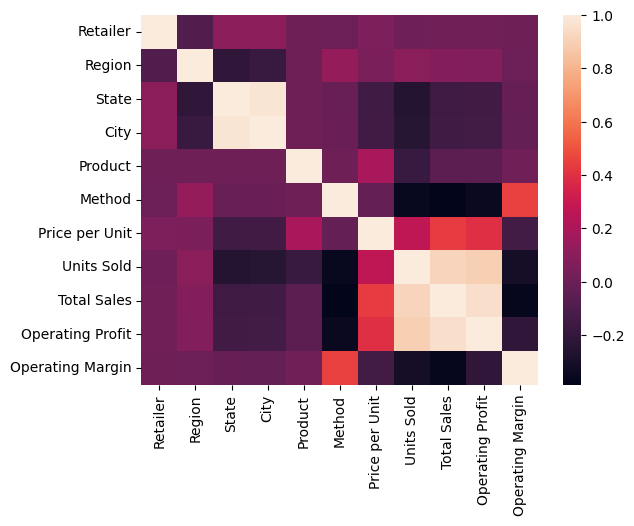

In [ ]:
# Tìm mối tương quan
corr=df2.corr()
print(corr)
# Trực quan hóa
sns.heatmap(df2.corr())

<mark>
Chúng ta có thể thấy rằng tổng doanh thu rõ ràng có mối tương quan cao với lợi nhuận hoạt động, giá bán trên mỗi đơn vị sản phẩm và số lượng sản phẩm bán ra. Nhưng mặt khác, các yếu tố như khu vực và nhà bán lẻ cũng có thể ảnh hưởng đến tổng doanh thu.